# Baseline: Neural Network (MLPClassifier)

## 0. Setup

In [1]:
import sys
sys.path.append("../..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

from src.config import TRAIN_CSV, TEST_CSV, SAMPLE_SUBMIT_CSV, SEED, N_FOLDS, TARGET_COL, ID_COL
from src.utils import seed_everything
from src.features import compute_train_stats, build_pipeline
from src.evaluation import cross_validate, calc_metrics
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
seed_everything(SEED)

with open("../../configs/default.yaml") as f:
    config = yaml.safe_load(f)

print("Feature version:", config["feature_version"])

Feature version: v1


## 1. Data Loading

In [2]:
train = pd.read_csv(TRAIN_CSV, index_col=0)
test = pd.read_csv(TEST_CSV, index_col=0)

y = train[TARGET_COL]
train = train.drop(columns=[TARGET_COL])

train_stats = compute_train_stats(train)

X_train = build_pipeline(train, version=config["feature_version"], train_stats=train_stats)
X_test = build_pipeline(test, version=config["feature_version"], train_stats=train_stats)

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
X_train.head()

X_train: (445, 14), X_test: (446, 14)


,pclass,sex,age,sibsp,parch,fare,embarked_C,embarked_Q,embarked_S,family_size,is_alone,log_fare,fare_per_person,pclass_sex
id,,,,,,,,,,,,,,
3,1,1,35.0,1,0,53.1000,0,0,1,2,0,3.990834,26.5500,11
4,3,0,35.0,0,0,8.0500,0,0,1,1,1,2.202765,8.0500,30
7,3,0,2.0,3,1,21.0750,0,0,1,5,0,3.094446,4.2150,30
9,2,1,14.0,1,0,30.0708,1,0,0,2,0,3.436268,15.0354,21
11,1,1,58.0,0,0,26.5500,0,0,1,1,1,3.316003,26.5500,11


## 2. Feature Engineering

In [3]:
print(f'Features: {list(X_train.columns)}')

Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_C', 'embarked_Q', 'embarked_S', 'family_size', 'is_alone', 'log_fare', 'fare_per_person', 'pclass_sex']


## 3. Cross-Validation

In [4]:
def model_fn():
    mlp_params = config["mlp"].copy()
    # Convert list to tuple for hidden_layer_sizes
    mlp_params["hidden_layer_sizes"] = tuple(mlp_params["hidden_layer_sizes"])
    return Pipeline([
        ("scaler", StandardScaler()),
        ("model", MLPClassifier(**mlp_params))
    ])

fold_metrics, mean_metrics = cross_validate(model_fn, X_train, y)

In [5]:
import pandas as pd

df_cv = pd.DataFrame(fold_metrics)
print("=== Fold-wise Results ===")
display(df_cv)
print(f"\n=== Mean Metrics ===")
for k, v in mean_metrics.items():
    print(f"  {k}: {v:.4f}")
print(f"\nStd Accuracy: {df_cv['accuracy'].std():.4f}")

=== Fold-wise Results ===


,accuracy,f1,logloss,auc,fold
0,0.820225,0.757576,0.456331,0.863208,0
1,0.764045,0.666667,0.500567,0.901205,1
2,0.741573,0.610169,0.593479,0.749476,2
3,0.808989,0.738462,0.468566,0.844602,3
4,0.662921,0.347826,0.661812,0.579365,4



=== Mean Metrics ===
  accuracy: 0.7596
  f1: 0.6241
  logloss: 0.5362
  auc: 0.7876

Std Accuracy: 0.0629


## 4. Train Full Model & Predict

In [6]:
final_model = model_fn()
final_model.fit(X_train, y)

y_pred_proba = final_model.predict_proba(X_test)[:, 1]
print(f"Predicted survival probability: mean={y_pred_proba.mean():.3f}, std={y_pred_proba.std():.3f}")

Predicted survival probability: mean=0.396, std=0.297


## 5. Submission

In [7]:
sample_submit = pd.read_csv(SAMPLE_SUBMIT_CSV, index_col=0, header=None)
sample_submit[1] = final_model.predict_proba(X_test)[:, 1]
sample_submit.to_csv("submit.csv", header=None)

print(f"Submission shape: {sample_submit.shape}")
print(f"Prediction stats: mean={sample_submit[1].mean():.3f}, std={sample_submit[1].std():.3f}")
sample_submit.head()

Submission shape: (446, 1)
Prediction stats: mean=0.396, std=0.297


,1
0,
0,0.155637
1,0.966407
2,0.479463
5,0.182296
6,0.333284


## 6. Analysis

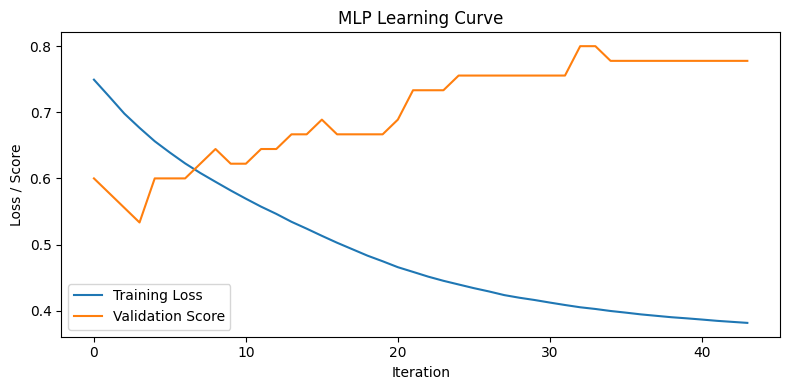

Final training loss: 0.3815
Number of iterations: 44


In [8]:
# Learning curve (loss over iterations)
mlp = final_model.named_steps["model"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp.loss_curve_, label="Training Loss")
if hasattr(mlp, "validation_scores_") and mlp.validation_scores_ is not None:
    ax.plot(mlp.validation_scores_, label="Validation Score")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss / Score")
ax.set_title("MLP Learning Curve")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Final training loss: {mlp.loss_curve_[-1]:.4f}")
print(f"Number of iterations: {mlp.n_iter_}")